# Machine Learning 1 (2026) Task 1: Predicting restaurant survival (class) 

This project builds a **binary classifier** that predicts whether a restaurant has **closed** from operational and review features in **`restaurants_train.csv`**.

The goal is to **compare three Machine Learning models**, tune them on labeled data, estimate performance with **balanced accuracy** on internal validation, and produce **`restaurant_submission.csv`** with predicted labels for **`restaurants_test.csv`**.




## Machine Learning approach



- **Logistic regression** — `LogisticRegression`, L2 penalty, solver `lbfgs`, `class_weight="balanced"`
- **k-nearest neighbors (k-NN)** — `KNeighborsClassifier` ( `n_neighbors`, `weights`)
- **Linear support vector machine (linear SVM)** — `LinearSVC`, linear kernel, `class_weight="balanced"`




## What do we predict?

| Item | Role in the project |
|------|---------------------|
| **Target** | **`status_closed`** — did the restaurant close? (0 = open, 1 = closed) |
| **Primary metric** | Balanced accuracy  |



## Data used in the project

- **`data/restaurants_train.csv`** — labeled rows for EDA, training, validation, and internal test splits  
- **`data/restaurants_test.csv`** — rows to score  
- **`data/restaurant_sample_submission.csv`** — required output format (`restaurant_id`, `status_closed`)



In [1]:
from pathlib import Path

# Reproducibility (splits, CV, etc.)
RANDOM_STATE = 42

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"

PATH_TRAIN = DATA_DIR / "restaurants_train.csv"
PATH_TEST = DATA_DIR / "restaurants_test.csv"
PATH_SAMPLE_SUBMISSION = DATA_DIR / "restaurant_sample_submission.csv"

TARGET_COL = "status_closed"
ID_COL = "restaurant_id"

In [2]:
for p in (PATH_TRAIN, PATH_TEST, PATH_SAMPLE_SUBMISSION):
    assert p.is_file(), f"Missing file: {p}"

print("ROOT:", ROOT)
print("Train:", PATH_TRAIN.name)
print("Test:", PATH_TEST.name)
print("Sample submission:", PATH_SAMPLE_SUBMISSION.name)
print("RANDOM_STATE:", RANDOM_STATE)

ROOT: /Users/aldaheirleonardodejesus/Desktop/ML PROJECT 
Train: restaurants_train.csv
Test: restaurants_test.csv
Sample submission: restaurant_sample_submission.csv
RANDOM_STATE: 42


## Project environment




In [3]:
import sys

venv_root = (ROOT / ".venv").resolve()
using_project_venv = Path(sys.prefix).resolve() == venv_root

print("Python:", sys.executable)
if using_project_venv:
    print("OK — using project .venv")
else:
    print("NOTE: Use project Python:", venv_root / "bin" / "python")


Python: /usr/local/bin/python3
NOTE: Use project Python: /Users/aldaheirleonardodejesus/Desktop/ML PROJECT /.venv/bin/python


---
# STEP  1 — Exploratory Data Analysis (EDA)

This phase inspects **`restaurants_train.csv`**: **class balance** on **`status_closed`**, **missing values**, **numeric distributions**, **category levels**, and **correlations** with the target.



In [4]:
# Import plotting and data libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120


In [5]:
# Load the training CSV; check size, duplicate IDs, and preview rows
train = pd.read_csv(PATH_TRAIN)
print("Shape:", train.shape)
print("Duplicate", ID_COL, ":", train[ID_COL].duplicated().sum())
train.head()


Shape: (33296, 86)
Duplicate restaurant_id : 0


,restaurant_id,has_photo,user_ratings_total,price_level,category_top20,type_meal_takeaway,type_meal_delivery,type_bar,type_cafe,type_night_club,...,gus_153354,gus_153398,gus_399257,gus_458173,gus_1548707_ratio,gus_60528_ratio,gus_1548707_net_ratio,gus_152173_ratio,affiliated,status_closed
0,753641611,True,408.0,1.0,Kebab,False,False,False,False,False,...,88.0,68.0,42.2,185.0,0.055978,0.434783,-0.378804,0.013662,False,0
1,995937340,True,203.0,NaN,Restaurant,False,False,False,False,False,...,508.0,284.0,39.0,273.0,0.058302,0.324528,-0.266226,0.017323,False,0
2,426018850,True,80.0,NaN,Pizzeria,False,False,False,False,False,...,7850.0,4360.0,30.7,149.0,0.082098,0.454545,-0.372448,0.004087,False,0
3,651806443,True,2.0,NaN,Restaurant,False,False,False,False,False,...,13051.0,5527.0,29.7,199.0,0.085288,0.361257,-0.275969,0.007401,False,0
4,658231705,False,1.0,NaN,Restaurant,False,False,False,False,False,...,177.0,90.0,41.5,138.0,0.066970,0.340909,-0.273939,0.002737,False,0


In [6]:
# Column types, missing %, and number of unique values per column
print("Dtypes:")
print(train.dtypes.value_counts())
info = pd.DataFrame(
    {
        "dtype": train.dtypes.astype(str),
        "missing_pct": (train.isna().mean() * 100).round(2),
        "nunique": train.nunique(dropna=False),
    }
)
info.sort_values("missing_pct", ascending=False).head(25)


Dtypes:
float64    65
int64      11
bool        7
object      3
Name: count, dtype: int64


,dtype,missing_pct,nunique
tagcat_payment_options,float64,71.62,6
price_level,float64,50.86,5
tagcat_social_inclusivity,float64,38.18,7
ratings_avg_12m_prior,float64,28.30,11401
ratings_num_12m_prior,float64,25.06,1206
ratings_avg_1m_prior,float64,24.64,1666
ratings_avg_9m_prior,float64,19.35,7970
ratings_avg_3m_prior,float64,18.59,4403
ratings_avg_6m_prior,float64,18.44,6438
catch_place_age_days_500m,float64,14.88,21045


,count,pct
status_closed,,
open (0),30028,90.19
closed (1),3268,9.81


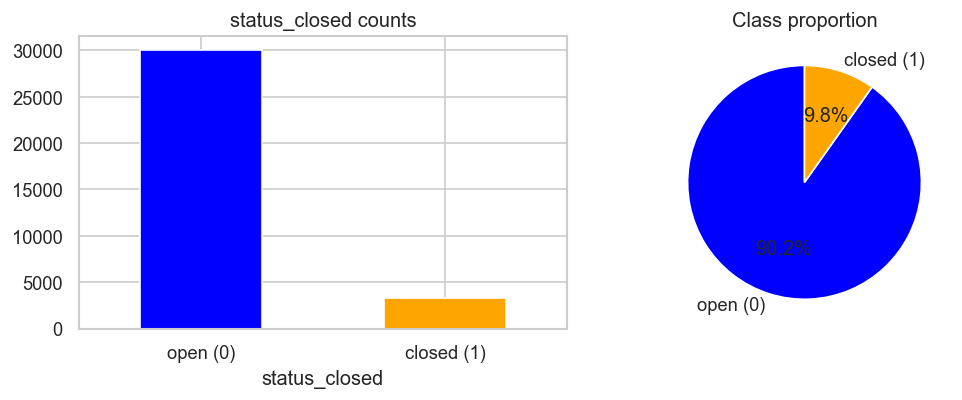

In [7]:
# Count open vs closed restaurants and plot class balance
y = train[TARGET_COL]
vc = y.value_counts().sort_index()
vc_pct = y.value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({"count": vc, "pct": vc_pct.round(2)}).rename(index={0: "open (0)", 1: "closed (1)"}))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
vc.plot(kind="bar", ax=ax[0], color=["blue", "orange"])
ax[0].set_title("status_closed counts")
ax[0].set_xticklabels(["open (0)", "closed (1)"], rotation=0)
ax[1].pie(vc, labels=["open (0)", "closed (1)"], autopct="%1.1f%%", colors=["blue", "orange"], startangle=90)
ax[1].set_title("Class proportion")
plt.tight_layout()
plt.show()


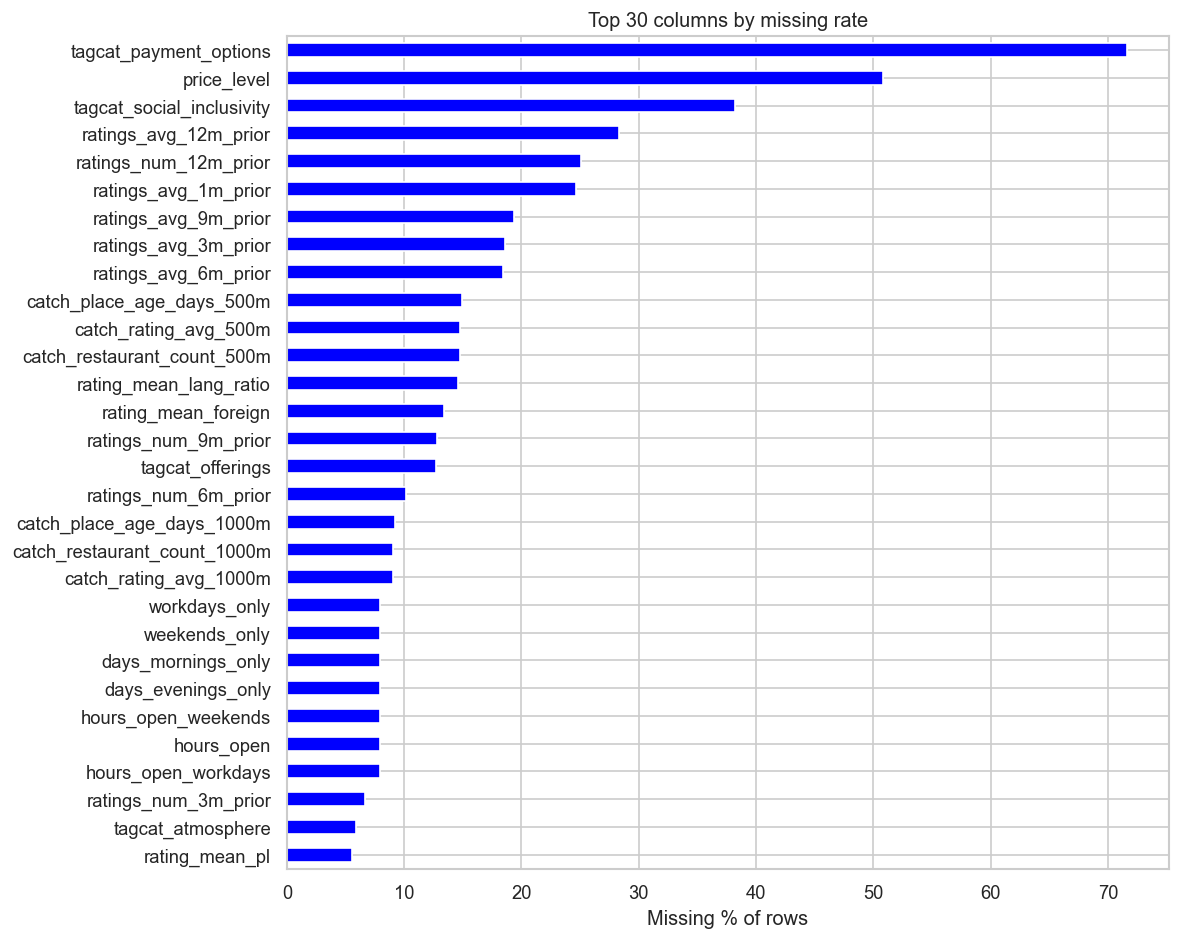

Columns with >50% missing: ['tagcat_payment_options', 'price_level']


In [8]:
# Bar chart of columns with the highest missing-data rates
miss = (train.isna().mean() * 100).sort_values(ascending=False)
miss_top = miss[miss > 0].head(30)
fig, ax = plt.subplots(figsize=(10, 8))
miss_top.sort_values().plot(kind="barh", ax=ax, color="blue")
ax.set_xlabel("Missing % of rows")
ax.set_title("Top 30 columns by missing rate")
plt.tight_layout()
plt.show()
print("Columns with >50% missing:", miss[miss > 50].index.tolist())


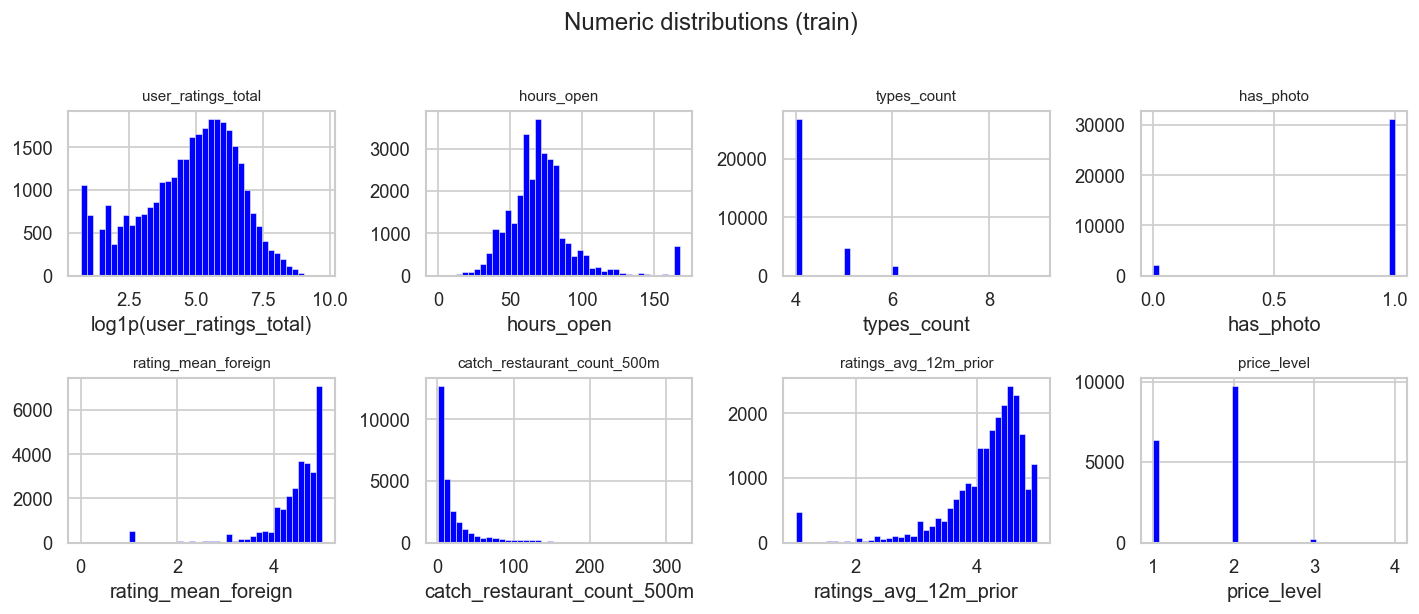

In [9]:
# Histograms for selected numeric features 
num_cols = train.select_dtypes(include=[np.number]).columns.drop([ID_COL, TARGET_COL], errors="ignore")
candidates = [
    "user_ratings_total",
    "hours_open",
    "types_count",
    "has_photo",
    "rating_mean_foreign",
    "catch_restaurant_count_500m",
    "ratings_avg_12m_prior",
    "price_level",
]
plot_cols = [c for c in candidates if c in train.columns]
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for ax, col in zip(axes.ravel(), plot_cols):
    s = train[col].dropna().astype(float)
    if col == "user_ratings_total" and len(s) and s.max() > 50:
        s = np.log1p(s)
        ax.set_xlabel("log1p(" + col + ")")
    else:
        ax.set_xlabel(col)
    ax.hist(s, bins=40, color="blue", edgecolor="white", linewidth=0.3)
    ax.set_title(col[:28], fontsize=9)
plt.suptitle("Numeric distributions (train)", y=1.02)
plt.tight_layout()
plt.show()


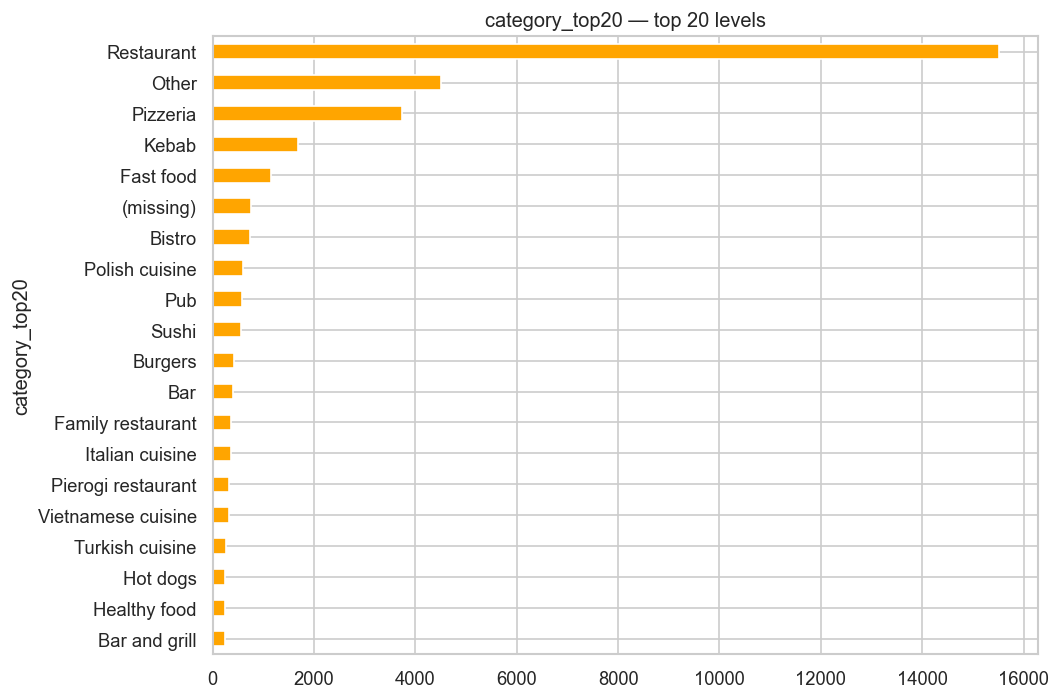

weekends_only value counts:
weekends_only
False    30615
NaN       2647
True        34
Name: count, dtype: int64
workdays_only value counts:
workdays_only
False    30613
NaN       2647
True        36
Name: count, dtype: int64


In [10]:
# Explore category_top20 and weekend/workday categorical fields
if "category_top20" in train.columns:
    ct = train["category_top20"].fillna("(missing)")
    top_cats = ct.value_counts().head(20)
    fig, ax = plt.subplots(figsize=(9, 6))
    top_cats.sort_values().plot(kind="barh", ax=ax, color="orange")
    ax.set_title("category_top20 — top 20 levels")
    plt.tight_layout()
    plt.show()
for c in ["weekends_only", "workdays_only"]:
    if c in train.columns:
        print(c, "value counts:")
        print(train[c].value_counts(dropna=False).head(10))


Top 20 |correlation| with status_closed :
tagcat_amenities        -0.142231
tagcat_atmosphere       -0.124433
first_review_year_max    0.122458
place_age_days          -0.121522
rating_pl               -0.121185
lang_pl_count           -0.119560
ratings_num_12m_prior   -0.110503
ratings_num_9m_prior    -0.108051
ratings_num_6m_prior    -0.107181
user_ratings_total      -0.106079
ratings_num_3m_prior    -0.105851
ratings_num_1m_prior    -0.101026
rating_foreign          -0.095297
ratings_avg_3m_prior    -0.091928
ratings_avg_6m_prior    -0.089296
ratings_avg_1m_prior    -0.084266
ratings_avg_9m_prior    -0.081329
ratings_avg_12m_prior   -0.079175
rating_3                -0.078178
tagcat_offerings        -0.073835
Name: status_closed, dtype: float64


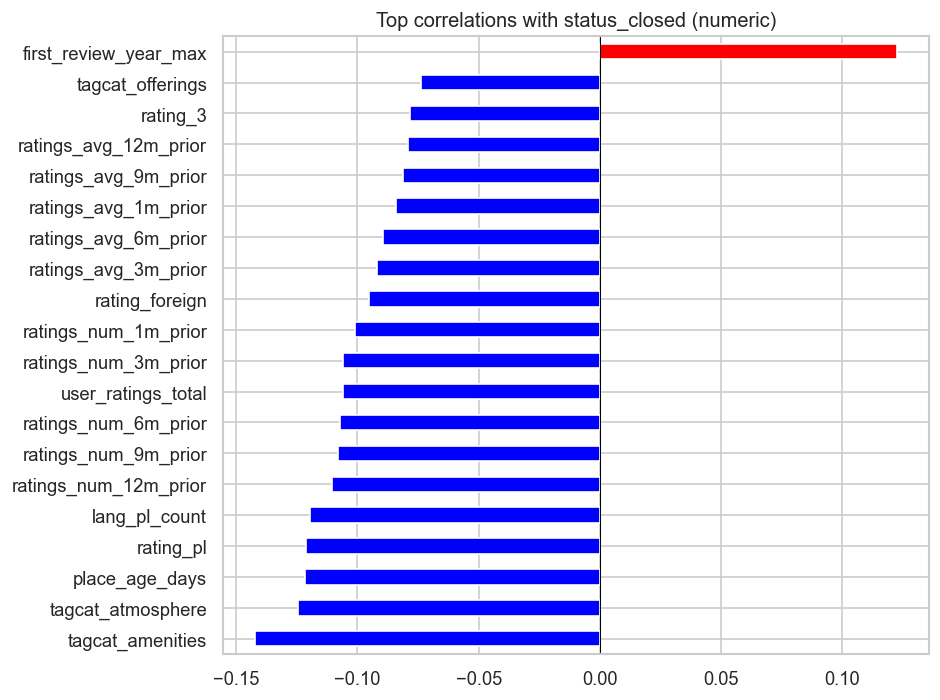

In [11]:
# List and plot numeric features most correlated with status_closed
num_for_corr = train.select_dtypes(include=[np.number]).copy()
corr_target = (
    num_for_corr.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values(key=np.abs, ascending=False)
)
print("Top 20 |correlation| with", TARGET_COL, ":")
print(corr_target.head(20))
fig, ax = plt.subplots(figsize=(8, 6))
top = corr_target.head(20).sort_values()
colors = ["red" if v > 0 else "blue" for v in top.values]
top.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Top correlations with " + TARGET_COL + " (numeric)")
ax.axvline(0, color="black", linewidth=0.6)
plt.tight_layout()
plt.show()


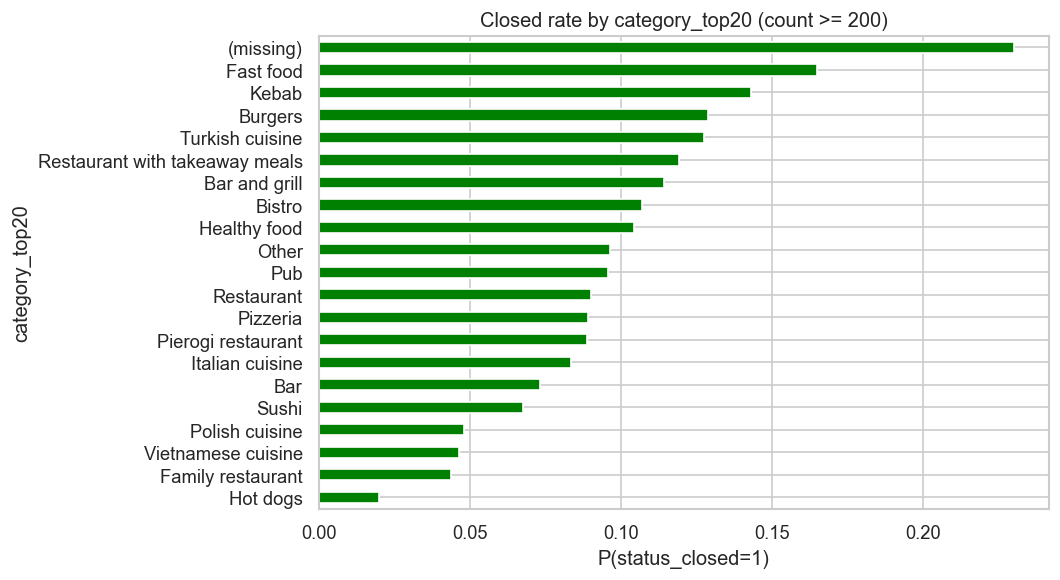

In [12]:
# Closure rate by restaurant category 
if "category_top20" in train.columns:
    g = (
        train.assign(category_top20=train["category_top20"].fillna("(missing)"))
        .groupby("category_top20", observed=False)[TARGET_COL]
        .agg(["mean", "count"])
        .rename(columns={"mean": "rate_closed"})
    )
    g = g[g["count"] >= 200].sort_values("rate_closed")
    fig, ax = plt.subplots(figsize=(9, 5))
    g["rate_closed"].plot(kind="barh", ax=ax, color="green")
    ax.set_title("Closed rate by category_top20 (count >= 200)")
    ax.set_xlabel("P(" + TARGET_COL + "=1)")
    plt.tight_layout()
    plt.show()


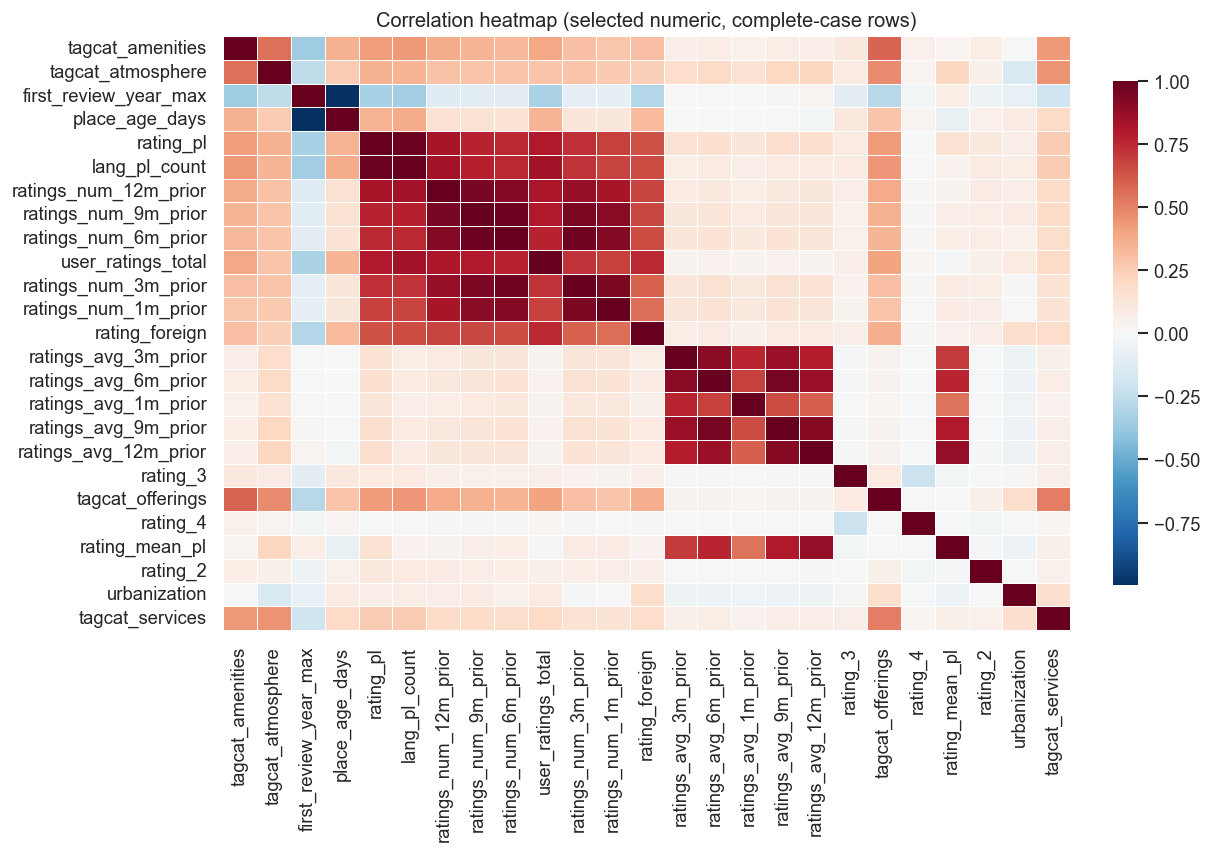

In [13]:
# Correlation heatmap for selected numeric features with low missingness
num_cols_heat = train.select_dtypes(include=[np.number]).columns.drop([ID_COL, TARGET_COL], errors="ignore")
miss_pct = train.isna().mean() * 100
low_miss = miss_pct[miss_pct < 30].index.drop([TARGET_COL], errors="ignore")
num_low = [c for c in low_miss if c in num_cols_heat]
if len(num_low) > 25:
    num_low = corr_target.loc[corr_target.index.intersection(num_low)].head(25).index.tolist()
sub = train[num_low].dropna()
cm = sub.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
sns.heatmap(
    cm,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    square=False,
    linewidths=0.3,
    cbar_kws={"shrink": 0.85},
)
ax.set_title("Correlation heatmap (selected numeric, complete-case rows)")
plt.show()
plt.close(fig)




Step 1 explores the labeled training file before any modeling. The load step shows 33,296 rows and 86 columns, with no duplicate `restaurant_id`, so each record is one restaurant. The dtype table reports mostly numeric and boolean predictors (65 float64, 11 int64,  bool) and three object (categorical) columns.

The missing-value review shows that `tagcat_payment_options` and `price_level` are missing in more than half of the rows. Other variables have lower gaps, with some review-history fields reaching roughly 28% missing.

The target `status_closed` is strongly imbalanced: about 9.8% closed and 90.2% open. 

Numeric correlations with the target highlight features such as `tagcat_amenities`, `place_age_days`, `first_review_year_max`, `rating_pl`, and `lang_pl_count`. The plots describe how the data is distributed and how variables relate to closure before preprocessing.


---
## STEP 2 - Splits and preprocessing

This phase builds **internal train / validation / test** splits from labeled data only and fits a reusable **`preprocess`** pipeline on the training slice.





In [14]:
DROP_COLS = ["tagcat_payment_options", "price_level"]  # >50% missing in EDA

# Skewed count-like numerics: log1p before scaling 
LOG1P_COLS = [
    "user_ratings_total",
    "ratings_num_1m_prior",
    "ratings_num_3m_prior",
    "ratings_num_6m_prior",
    "ratings_num_9m_prior",
    "ratings_num_12m_prior",
    "restaurants_per_capita",
    "review_length_avg",
    "poi_count_500m",
]


def add_engineered_features(df):
    """Add log1p columns used by preprocess (train / val / test / submit)."""
    out = df.copy()
    for c in LOG1P_COLS:
        if c in out.columns:
            out[f"{c}_log1p"] = np.log1p(out[c].clip(lower=0))
    return out


train = pd.read_csv(PATH_TRAIN)
# Build feature matrix X and target y 
X = add_engineered_features(
    train.drop(columns=[TARGET_COL, ID_COL] + DROP_COLS, errors="ignore")
)
y = train[TARGET_COL]

cat_cols = [
    c
    for c in X.columns
    if pd.api.types.is_object_dtype(X[c]) or pd.api.types.is_string_dtype(X[c])
]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Rows: {len(X)} | dropped: {DROP_COLS}")
print(f"Features: {len(num_cols)} numeric/bool, {len(cat_cols)} categorical")
print(f"Engineered log1p columns: {sum(1 for c in LOG1P_COLS if c in train.columns)}")


Rows: 33296 | dropped: ['tagcat_payment_options', 'price_level']
Features: 88 numeric/bool, 3 categorical
Engineered log1p columns: 9


In [15]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import LinearSVC

# Stratified 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

for name, yt in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5} n={len(yt):5}  P(closed)={yt.mean():.4f}")


train n=23307  P(closed)=0.0982
val   n= 4994  P(closed)=0.0981
test  n= 4995  P(closed)=0.0981


In [16]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            min_frequency=0.02,
        ),
    ),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

prep_train = preprocess.fit_transform(X_train)
print("Preprocessed shapes (train, val, test):",
      prep_train.shape,
      preprocess.transform(X_val).shape,
      preprocess.transform(X_test).shape)


Preprocessed shapes (train, val, test): (23307, 155) (4994, 155) (4995, 155)




Step 2 prepares the data for modeling. After dropping sparse columns (`DROP_COLS`), the feature matrix contains 33,296 restaurants with 88 numeric or boolean columns, three categorical columns, and nine additional log1p features for skewed counts. The stratified split produces 23,307 training, 4,994 validation, and 4,995 internal test rows; the proportion of closed restaurants stays near 0.098 in each split, so the class mix is preserved.

The preprocessing pipeline is fitted on the training data only and expands inputs to 155 columns after median imputation, missingness indicators, and one-hot encoding. Validation and test sets are transformed with that same fitted pipeline to prevent leakage. 

---
## Step 3 - Models, tuning, and submission

This phase compares three Machine Learning classifiers, tunes hyperparameters, selects a **winner** by validation **balanced accuracy**, and writes **`restaurant_submission.csv`**.




In [17]:
# Tuning setup (fast = wider C grids for log/SVM, one k-NN setting)
TUNING_MODE = "fast"  

if TUNING_MODE == "fast":
    n_cv_splits = 2
    C_lr = [0.05, 0.1, 0.5, 1.0, 5.0]
    C_svm = [0.5, 1.0, 5.0, 10.0]
    knn_neighbors = [11]
    knn_weights = ["distance"]
elif TUNING_MODE == "standard":
    n_cv_splits = 3
    C_lr = [0.05, 0.1, 0.5, 1.0, 5.0]
    C_svm = [0.5, 1.0, 5.0, 10.0]
    knn_neighbors = [5, 11, 21]
    knn_weights = ["uniform", "distance"]
else:
    raise ValueError('TUNING_MODE must be "fast" or "standard"')

cv = StratifiedKFold(n_splits=n_cv_splits, shuffle=True, random_state=RANDOM_STATE)
grid_kw = dict(scoring="balanced_accuracy", cv=cv, n_jobs=1)

n_lr = len(C_lr)
n_svm = len(C_svm)
n_knn = len(knn_neighbors) * len(knn_weights)
print(
    f"Phase 3 tuning: {TUNING_MODE.upper()} | CV folds={n_cv_splits} |",
    f"grid fits (LR/SVM/kNN): {n_lr * n_cv_splits}/{n_svm * n_cv_splits}/{n_knn * n_cv_splits}",
)


def make_pipe(classifier):
    """Pipeline: same preprocess clone + one classifier."""
    return Pipeline([("prep", clone(preprocess)), ("clf", classifier)])


# METHOD 1 — Logistic regression (L2, balanced classes)

search_lr = GridSearchCV(
    make_pipe(
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            solver="lbfgs",
        )
    ),
    {"clf__C": C_lr},
    **grid_kw,
)


# METHOD 2 — k-Nearest neighbors

search_knn = GridSearchCV(
    make_pipe(KNeighborsClassifier(n_jobs=1)),
    {"clf__n_neighbors": knn_neighbors, "clf__weights": knn_weights},
    **grid_kw,
)


# METHOD 3 — Linear SVM (LinearSVC — fast linear kernel SVM)

search_svc_linear = GridSearchCV(
    make_pipe(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=3000)
    ),
    {"clf__C": C_svm},
    **grid_kw,
)


# Train all three and pick the winner by validation balanced accuracy

searches = {
    "log_reg_l2": search_lr,
    "knn": search_knn,
    "svc_linear": search_svc_linear,
}
for gs in searches.values():
    gs.fit(X_train, y_train)

rows = []
for label, gs in searches.items():
    val_bal = balanced_accuracy_score(y_val, gs.best_estimator_.predict(X_val))
    rows.append(
        {
            "model": label,
            "cv_balanced_acc_mean": gs.best_score_,
            "val_balanced_acc": val_bal,
            "best_params": gs.best_params_,
        }
    )

results_phase3 = pd.DataFrame(rows)
display(results_phase3.sort_values("val_balanced_acc", ascending=False).reset_index(drop=True))

winner_label = results_phase3.loc[results_phase3["val_balanced_acc"].idxmax(), "model"]
winner_search = searches[winner_label]
print("Winner (by validation balanced accuracy):", winner_label)

# Threshold tuning only if logistic regression wins (not used for svc_linear / knn)
winner_threshold = 0.5
if winner_label == "log_reg_l2":
    proba_val = winner_search.best_estimator_.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 91)
    scores = [
        balanced_accuracy_score(y_val, (proba_val >= t).astype(int)) for t in thresholds
    ]
    best_i = int(np.argmax(scores))
    winner_threshold = float(thresholds[best_i])
    print(
        "Best threshold on validation (log_reg_l2):",
        round(winner_threshold, 4),
        "| val_balanced_acc:",
        round(float(scores[best_i]), 4),
    )


Phase 3 tuning: FAST | CV folds=2 | grid fits (LR/SVM/kNN): 10/8/2


,model,cv_balanced_acc_mean,val_balanced_acc,best_params
0,svc_linear,0.666290,0.671898,{'clf__C': 1.0}
1,log_reg_l2,0.666337,0.668926,{'clf__C': 0.1}
2,knn,0.506968,0.505478,"{'clf__n_neighbors': 11, 'clf__weights': 'dist..."


Winner (by validation balanced accuracy): svc_linear


In [18]:
# Uses the winner chosen previously 

X_full = add_engineered_features(
    train.drop(columns=[TARGET_COL, ID_COL] + DROP_COLS, errors="ignore")
)
y_full = train[TARGET_COL]

# Refit winner on all labeled training rows 
final_model = clone(winner_search.best_estimator_)
final_model.fit(X_full, y_full)

test_df = pd.read_csv(PATH_TEST)
X_submit = add_engineered_features(test_df.drop(columns=[ID_COL] + DROP_COLS, errors="ignore"))

# Logistic regression: use tuned probability threshold; SVM/k-NN: default predict()
if winner_label == "log_reg_l2":
    y_pred = (final_model.predict_proba(X_submit)[:, 1] >= winner_threshold).astype(int)
else:
    y_pred = final_model.predict(X_submit)

submission = pd.DataFrame({ID_COL: test_df[ID_COL], TARGET_COL: y_pred})
sub_path = ROOT / "restaurant_submission.csv"
submission.to_csv(sub_path, index=False)
print("Saved:", sub_path, "| rows:", len(submission))

# Quick check: winner evaluated on internal test (still 70% train )
holdout = balanced_accuracy_score(y_test, winner_search.best_estimator_.predict(X_test))
print("Internal test balanced accuracy (winner, 70% train only):", round(holdout, 4))


Saved: /Users/aldaheirleonardodejesus/Desktop/ML PROJECT /restaurant_submission.csv | rows: 8325
Internal test balanced accuracy (winner, 70% train only): 0.6768




**Linear SVM** (`svc_linear`, `C = 1.0`) wins on validation **balanced accuracy** (**0.6719**), slightly above logistic regression (**0.6689**) and well above k-NN (**0.5055**). 

---
## Step 4 — Evaluation and interpretation

We report how the winner behaves on the **internal 15% test** split.




Winner: svc_linear
              precision    recall  f1-score   support

           0     0.9515    0.6659    0.7835      4505
           1     0.1830    0.6878    0.2890       490

    accuracy                         0.6681      4995
   macro avg     0.5672    0.6768    0.5363      4995
weighted avg     0.8761    0.6681    0.7350      4995



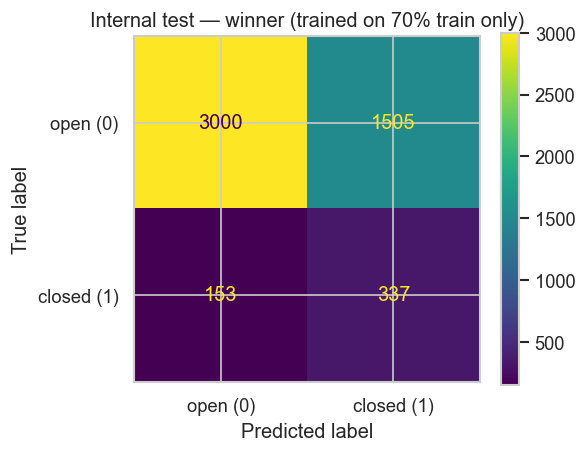

In [19]:
eval_model = winner_search.best_estimator_
y_test_hat = eval_model.predict(X_test)

print("Winner:", winner_label)
print(classification_report(y_test, y_test_hat, digits=4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_hat,
    display_labels=["open (0)", "closed (1)"],
    ax=ax,
    colorbar=True,
)
ax.set_title("Internal test — winner (trained on 70% train only)")
plt.tight_layout()
plt.show()
plt.close(fig)





On the internal test set (**4,995** rows), **`svc_linear`** reaches **balanced accuracy 0.6768**. **Open** restaurants are found with high precision (**0.95**) but moderate recall (**0.67**); **closed** ones are caught often (**recall 0.69**) but with many false alarms (**precision 0.18**).


---
## STEP 5 — Report summary




In [20]:
row = results_phase3.loc[results_phase3["model"] == winner_label].iloc[0]
holdout = balanced_accuracy_score(y_test, winner_search.best_estimator_.predict(X_test))

print("Model comparison (validation balanced accuracy):")
display(results_phase3.sort_values("val_balanced_acc", ascending=False).reset_index(drop=True))

print(f"\nWinner: {winner_label} | best_params: {row['best_params']}")
print(f"CV mean: {row['cv_balanced_acc_mean']:.4f} | Val: {row['val_balanced_acc']:.4f} | Internal test: {holdout:.4f}")
if winner_label == "log_reg_l2":
    print(f"Decision threshold (log_reg): {winner_threshold:.4f}")



Model comparison (validation balanced accuracy):


,model,cv_balanced_acc_mean,val_balanced_acc,best_params
0,svc_linear,0.666290,0.671898,{'clf__C': 1.0}
1,log_reg_l2,0.666337,0.668926,{'clf__C': 0.1}
2,knn,0.506968,0.505478,"{'clf__n_neighbors': 11, 'clf__weights': 'dist..."



Winner: svc_linear | best_params: {'clf__C': 1.0}
CV mean: 0.6663 | Val: 0.6719 | Internal test: 0.6768


---
## STEP 6 — Hand-in checks

We verify that **`restaurant_submission.csv`** matches **`restaurant_sample_submission.csv`**: column names, row count, unique **`restaurant_id`**, binary **`status_closed`**, and ID order aligned with **`restaurants_test.csv`**.




In [21]:
sub_path = ROOT / "restaurant_submission.csv"
assert sub_path.is_file(), "Run Phase 3 (`phase3-submit`) first."

sample = pd.read_csv(PATH_SAMPLE_SUBMISSION)
sub = pd.read_csv(sub_path)
test_ids = pd.read_csv(PATH_TEST)[ID_COL]

assert list(sub.columns) == list(sample.columns)
assert len(sub) == len(test_ids)
assert sub[ID_COL].is_unique
assert sub[TARGET_COL].isin([0, 1]).all()
assert sub[ID_COL].equals(test_ids)

print("Hand-in checks: OK |", sub_path.name, "| rows:", len(sub))


Hand-in checks: OK | restaurant_submission.csv | rows: 8325


## FINAL CONCLUSION

We predict **open** vs **closed** restaurants with three Machine Learning  models on a stratified **70 / 15 / 15** split, after standard preprocessing and `class_weight="balanced"` grid search.

The winner is **linear SVM** (`svc_linear`, `C = 1.0`): validation **balanced accuracy 0.6719** (above logistic **0.6689** and k-NN **0.5055**), **0.6768** on the internal test. It catches most **closed** cases (**recall ~0.69**) but with low **precision (~0.18)** in an imbalanced dataset. **8,325** predictions are in **`restaurant_submission.csv`**. 
